In [1]:
from functions import *
import numpy as np
import pickle # For saving/loading data

In [2]:
# Load constituent particle configurations (orbits) for a 3x3 lattice

with open('Orbits.pickle', 'rb') as handle:
    orbits = pickle.load(handle)

print(orbits[-1]) # Note we DO NOT simulate this orbit (single isolated particle) as it has no interaction so does not contribute to the overall dynamcis
# We consider how much of the overall distribution is built from single isolated particles

[array([[0, 0, 0],
       [0, 1, 0],
       [0, 0, 0]])]


In [3]:
# Define Ramsey measurements parameters
# Note the parameters of the larger distribution are not relavent here (e.g. the overall particle density)


# Defining 200 delay times between the pi pulses of a Ramsey sequence to simulate
# These time are evenly spaced between 0s and 350 * the duration of each pulse

intervals = 200
holds = np.linspace(0, 350 * pulse_time, intervals)

# Define the interaction strength between particles, J (Hz), the detuning of the driving field, det (Hz), and how 'stretched' the lattice is , ax/ay
J, det, ax, ay = 1200, 0, 1, 1

# Define the direction of the quantixation axis (in this case it points out of the 2D plane of particles creating an isotropic interaction) 
theta, phi = 0, 0

In [6]:
# Simulate the Ramsey measurement for each orbit

import time # For recording how long the simulations took
start_time = time.time()

orbit_dynamics = [] # To hold results

# For tracking progress
progress = 0
orbit_no = len(orbits)

for i in orbits[:-1]: # Single isolated particles do not contribute to the overall dynamcis
    config = i[-1] # Pick the repersentative of the orbit
    occ_sites = np.nonzero(config.flatten())[0] # Find which sites are occupied in the 3x3 grid (to construct the Hamiltonian)
    up_probabilities = []

    Ly, Lx = config.shape # Some orbits may be smaller then 3x3

    particles = int(np.sum(config))

    # Define the initial state of the system (all particles in the 'down' spin state)
    initial_state = np.zeros(2**particles)
    initial_state[-1] = 1
    
    # Simulate the Ramsey measurement to obtain the dynamics of the orbit
    for i in holds:
        sim_times = np.linspace(0, 2*pulse_time + i, 3) # Times which are simulated for each hold time between pi pulses (inculdes 3 times for the )

        params = [pulse_time, i, rabi_frequency] # Parameters for the pulse sequence

        # Build Hamiltonian for specific configurations/repersentative
        Hamiltonian = construct_H(particles, J, det, ax, ay, Lx, params, pulse_ramsey, theta=theta, phi=phi, Ly=Ly, occupied_sites=occ_sites)

        # Simulate the dynamics under the defined pulse sequence and extract the resulting number of 'up' spin states
        populations = Hamiltonian.evolve(initial_state, 0, sim_times)
        ups = sparse_up_prob(particles, populations)

        up_probabilities.append(ups[-1]) # Only record final state (after pulse sequence/Ramsey pulse)

    # Show progress of code
    progress += 1
    print(str(progress) + '/' + str(orbit_no) + ' Completed')
    
    # Add the overall dynamics of the orbit to the results
    orbit_dynamics.append(np.array(up_probabilities))

print("--- %s seconds ---" % (time.time() - start_time))

# Save the dynamics for every orbit (under our specific defined parameters/pulse sequence)
with open('Orbit_Ramseys.pickle', 'wb') as handle:
    pickle.dump(orbit_dynamics, handle, protocol=pickle.HIGHEST_PROTOCOL)

c:\Users\Joe\Desktop\DipolarSpin\Examples\functions.py:61: RuntimeWarning: invalid value encountered in scalar divide
  angle = np.arccos(displacement @ quan_axis/r)


1/85 Completed
2/85 Completed
3/85 Completed
4/85 Completed
5/85 Completed
6/85 Completed
7/85 Completed
8/85 Completed
9/85 Completed
10/85 Completed
11/85 Completed
12/85 Completed
13/85 Completed
14/85 Completed
15/85 Completed
16/85 Completed
17/85 Completed
18/85 Completed
19/85 Completed
20/85 Completed
21/85 Completed
22/85 Completed
23/85 Completed
24/85 Completed
25/85 Completed
26/85 Completed
27/85 Completed
28/85 Completed
29/85 Completed
30/85 Completed
31/85 Completed
32/85 Completed
33/85 Completed
34/85 Completed
35/85 Completed
36/85 Completed
37/85 Completed
38/85 Completed
39/85 Completed
40/85 Completed
41/85 Completed
42/85 Completed
43/85 Completed
44/85 Completed
45/85 Completed
46/85 Completed
47/85 Completed
48/85 Completed
49/85 Completed
50/85 Completed
51/85 Completed
52/85 Completed
53/85 Completed
54/85 Completed
55/85 Completed
56/85 Completed
57/85 Completed
58/85 Completed
59/85 Completed
60/85 Completed
61/85 Completed
62/85 Completed
63/85 Completed
6

In [7]:
# Define density of uniform distribution of occupied sites in a lattice
lat_filling = 0.0544

# Load the Ramsey dynamics for each 3x3 particle configuration (generated above)
with open('Orbit_Ramseys.pickle', 'rb') as handle:
    orbit_dynamics = pickle.load(handle)

c:\Users\Joe\Desktop\DipolarSpin\.venv\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Joe\Desktop\DipolarSpin\.venv\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


[[0 0 0 0 0]
 [0 1 0 1 0]
 [0 0 0 0 0]]
[[0 0 0 0]
 [0 1 1 0]
 [0 0 0 0]]
[[0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]]


NameError: name 'particles_per_sample' is not defined

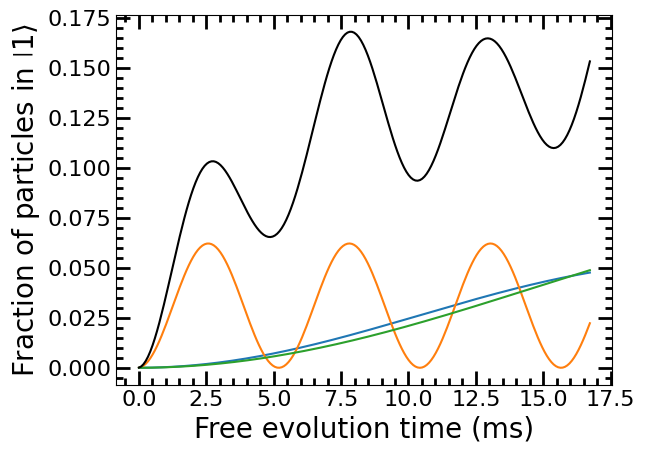

In [ ]:
##################################################################################################
fig, axes = plt.subplots(1, 1)
##################################################################################################


axes.set_ylabel(r"Fraction of particles in $\left|1\right>$", fontsize=20)
axes.set_xlabel('Free evolution time (ms)', fontsize=20)

overall_dynamics = np.zeros(intervals)
for i, n in zip(orbits[:-1] , orbit_dynamics):
    
    symm = len(i) # Number of particle configurations in this orbit (effects the proportion of the distribution consisting by the orbit)
    particles = i[0].sum() # Number of particles in each member of the orbit
    h, o = i[0].shape # Dimensions of each orbit memeber (3x3 or less)
    empty_sites = h*o - particles
    
    # Model the proportion of the uniform distribution which is built from members of the orbit for each density
    model = gen_poly(symm, particles, empty_sites)
    coef = model(lat_filling)


    ##################################################################################################
    # Plot significant contributing component Ramsey measurements and print a member of the corresponding orbit
    if coef >= 0.05:
        axes.plot(holds*(10**3), coef*np.array(n))
        print(i[0])
    ##################################################################################################


    # Add the weighted dynamics of the orbit to the final result for the overall dynamics for the large distribution
    overall_dynamics = overall_dynamics + coef*np.array(n)


##################################################################################################
# Format the final plot
axes.plot(holds*(10**3), overall_dynamics, color='black')

axes.minorticks_on()
axes.tick_params(which='major', length=10, width=2, direction='in', bottom=True, top=True, left=True, right=True)
axes.tick_params(which='minor', length=5, width=2, direction='in', bottom=True, top=True, left=True, right=True)
yticks = np.linspace(0, 0.35, 8)
#axes.set_yticks(yticks) 
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
plt.savefig(f'Consitiuent_Method_Particle_Ramsey_{J}Hz_{lat_filling}_filling.png', bbox_inches='tight')
    
plt.show(block=False)
##################################################################################################